In [ ]:
!pip install -q pandas matplotlib statsmodels scikit-learn seaborn scipy tabulate

# Time Series Forecasting (ARIMA)

This analysis uses the historical monthly airline passengers dataset covering January 1949 to December 1960. The series represents the total number of passengers carried each month and is a classic time series in statistical analysis. The goal is to apply an ARIMA (AutoRegressive Integrated Moving Average) model to model and forecast future passenger counts, first assessing assumptions such as stationarity and using statistical tools to select appropriate model parameters.

# 1. Load and visualize the data

The image shows a line chart of monthly airline passengers from 1949 to 1960. There is a general upward trend over the years and a clear seasonal pattern within each year, with higher peaks in summer months and lower values in winter months.

In [ ]:
!pip install pandas matplotlib statsmodels

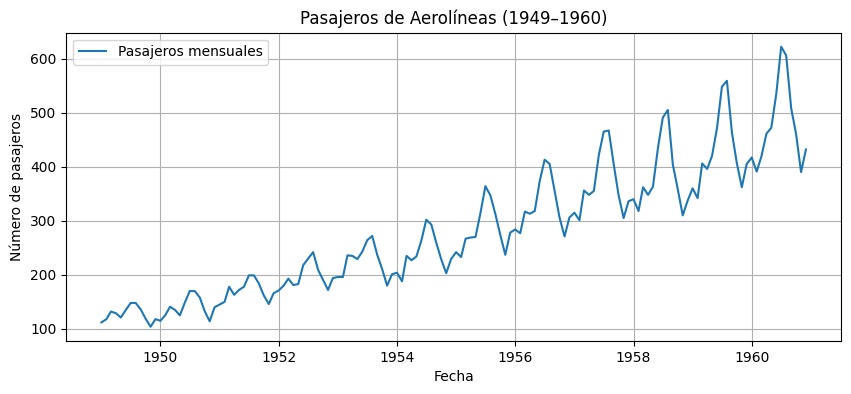

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset real de pasajeros mensuales
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['pasajeros']

# Visualizar la serie temporal
plt.figure(figsize=(10, 4))
plt.plot(df['pasajeros'], label='Pasajeros mensuales')
plt.title('Pasajeros de Aerolíneas (1949–1960)')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.grid(True)
plt.legend()
plt.show()


# 2 Verify ARIMA assumptions


## 2.1 Stationarity (Dickey-Fuller)

To determine if the passenger series can be used directly in an ARIMA model, we first apply the augmented Dickey-Fuller test. This test indicates whether the series is stationary (i.e., its behavior does not change significantly over time). If the p-value is greater than 0.05, the series is not stationary and requires transformation (e.g., differencing). If the p-value is less than or equal to 0.05, the series is stationary and can be used as is.

In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df['pasajeros'])
print("ADF Statistic:", resultado_adf[0])
print("p-valor:", resultado_adf[1])

if resultado_adf[1] > 0.05:
    print("👉 La serie NO es estacionaria (se necesita diferenciación).")
else:
    print("✅ La serie es estacionaria.")


ADF Statistic: 0.8153688792060498
p-valor: 0.991880243437641
👉 La serie NO es estacionaria (se necesita diferenciación).


## 2.2 Autocorrelation plots (ACF and PACF)

ACF and PACF plots help visualize how past values relate to current values. ACF shows correlation at different lags, helping detect repeating patterns. PACF shows the direct relationship between the series and its lags, removing intermediate effects. These plots are key to choosing ARIMA parameters p (AR) and q (MA).

<Figure size 1200x400 with 0 Axes>

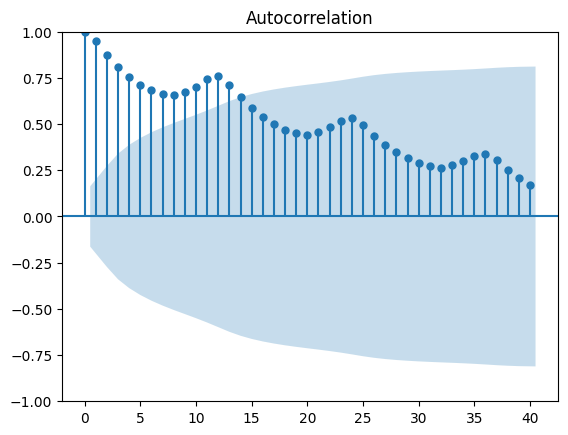

<Figure size 1200x400 with 0 Axes>

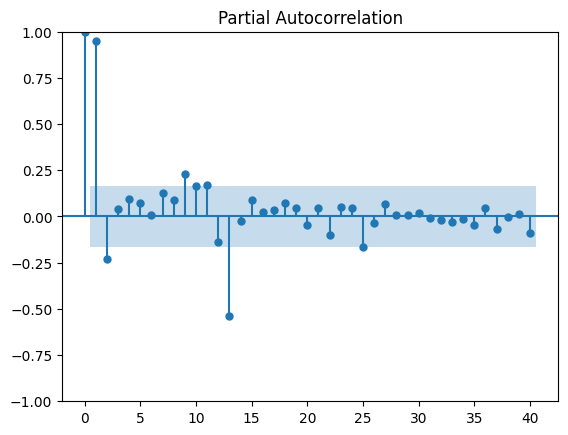

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(df['pasajeros'], lags=40)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df['pasajeros'], lags=40)
plt.show()


* **Autocorrelation:** The ACF plot shows how current passenger counts relate to past counts. Bars outside the shaded area indicate significant correlation. Nearby lags are strongly correlated, and the pattern repeats approximately every 12 periods, suggesting annual seasonality. A gradual decline in bar heights as lag increases indicates decreasing influence of older values, while recurring peaks confirm strong seasonality.

* **Partial autocorrelation:** The PACF isolates direct relationships between the current value and past lags, removing intermediate effects. Bars beyond the shaded area indicate significant partial correlation. We observe notable peaks at early lags (especially lag 1) and around lag 12, suggesting strong influence from the immediate previous month and the same month in the previous year. Most other bars lie within the shaded area, indicating a smaller direct contribution.

## 2.3 Differencing the series.

In [ ]:
df_diff = df['pasajeros'].diff().diff().dropna()

# Verificar estacionariedad tras diferenciar
resultado_adf_diff = adfuller(df_diff)
print("ADF después de diferenciar:", resultado_adf_diff[0])
print("p-valor:", resultado_adf_diff[1])


ADF después de diferenciar: -16.384231542468513
p-valor: 2.7328918500142026e-29


After applying a double difference to the passenger series, we ran the augmented Dickey-Fuller (ADF) test on the transformed series. The ADF statistic was -16.38 with a p-value near zero (2.73e-29), indicating the series no longer shows trends or structural variations and is stationary. Therefore, it is suitable for modeling with techniques like ARIMA.

## 2.4 Visualizing the differenced series

We now plot the time series after applying two differences, which helps stabilize the mean and remove trends. The plot allows visual inspection to confirm the transformed series behaves more like a stationary process and verifies preprocessing effectiveness before fitting an ARIMA model.

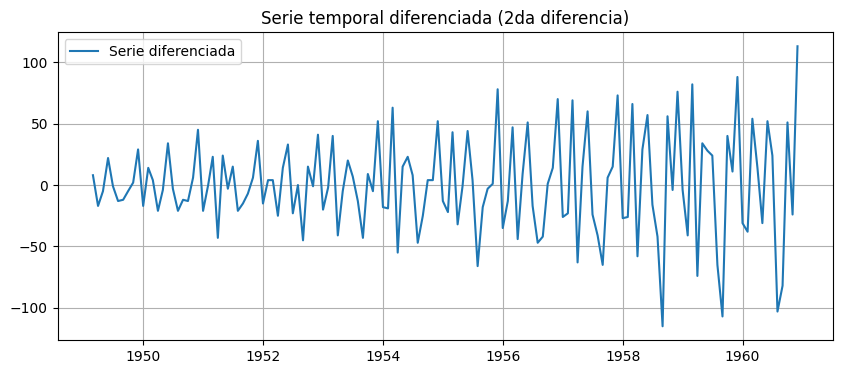

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_diff, label='Serie diferenciada')
plt.title('Serie temporal diferenciada (2da diferencia)')
plt.grid(True)
plt.legend()
plt.show()

# 3 Fit ARIMA model
The ARIMA model is fitted with parameters (2, 1, 2), meaning two autoregressive terms, one differencing, and two moving average terms.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Ajustar ARIMA(2,1,2) como ejemplo
modelo = ARIMA(df['pasajeros'], order=(2,1,2))
resultado = modelo.fit()
print(resultado.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              pasajeros   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Tue, 06 May 2025   AIC                           1353.347
Time:                        22:10:58   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.814      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The ARIMA(2,1,2) model fitted to the passenger series shows good overall performance. The coefficients of the autoregressive (AR) and moving average (MA) components are significant (all with p-values < 0.05), indicating each contributes value to the prediction. The AIC (1353.347) and BIC (1368.161) are useful for comparing this model to others (lower is better), and are within reasonable ranges here. Additionally, the Ljung-Box test returned a high p-value (0.59), suggesting residuals are not autocorrelated, which is desirable.

On the other hand, the model shows some heteroscedasticity (H test p-value = 0.00), meaning the error variance is not constant over time, which may slightly affect precision. However, the residuals appear approximately normally distributed, with kurtosis around 3.14 and mild skewness (0.27). In summary, the model explains the series well and is usable, though there may be room for improvement to further refine forecasts.

# 4 Evaluate model residuals

4.1 Residuals plot

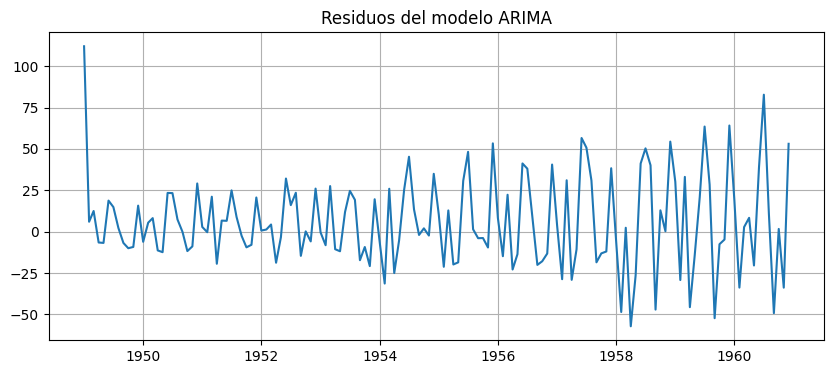

In [ ]:
residuos = resultado.resid

plt.figure(figsize=(10, 4))
plt.plot(residuos)
plt.title('Residuos del modelo ARIMA')
plt.grid(True)
plt.show()


4.2 Residuals autocorrelation (should resemble white noise)

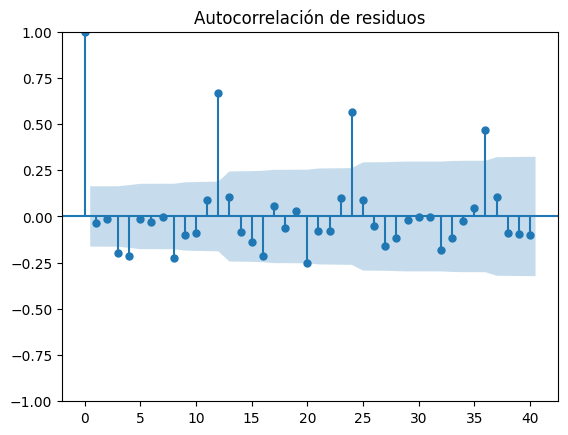

In [ ]:
plot_acf(residuos, lags=40)
plt.title("Autocorrelación de residuos")
plt.show()


The plot shows the autocorrelation of residuals from the ARIMA(2,1,2) model and suggests the model has not fully captured the temporal structure of the data. While many points lie within the expected confidence band, some lags such as 13, 24 and 36 show significant autocorrelations, indicating remaining dependence in the errors. This means the model could be improved, as ideally there should be no correlation between residuals at different lags.

4.3 Ljung-Box test (residuals should be uncorrelated)

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(lb_test)

if lb_test['lb_pvalue'].values[0] > 0.05:
    print("✅ No hay autocorrelación significativa en los residuos.")
else:
    print("⚠️ Hay autocorrelación en los residuos.")

      lb_stat  lb_pvalue
10  24.077141   0.007398
⚠️ Hay autocorrelación en los residuos.


The Ljung-Box test p-value is 0.007, which is less than 0.05, indicating significant autocorrelation in the residuals. This means the ARIMA model is not fully capturing the temporal structure and some patterns remain unexplained.

4.4 Residual normality (histogram and Shapiro-Wilk test)

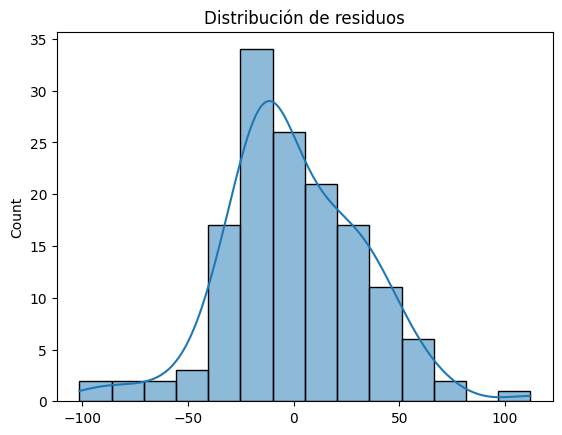

Shapiro-Wilk p-valor: 0.06495682198284028
✅ Los residuos parecen normales.


In [ ]:
import seaborn as sns
from scipy.stats import shapiro

sns.histplot(residuos, kde=True)
plt.title('Distribución de residuos')
plt.show()

stat, p = shapiro(residuos)
print("Shapiro-Wilk p-valor:", p)

if p > 0.05:
    print("✅ Los residuos parecen normales.")
else:
    print("⚠️ Los residuos NO siguen una distribución normal.")


The Shapiro-Wilk p-value is approximately 0.065, which is greater than 0.05, so we do not reject normality. In other words, the model residuals appear to follow a normal distribution, which is a good indication for the ARIMA model's validity.

# 5: Model validation (forecast vs actual)

5.1 Split train and test

In [ ]:
train = df['pasajeros'][:-12]
test = df['pasajeros'][-12:]

5.2 Fit model and forecast

In [ ]:
modelo_val = ARIMA(train, order=(2,1,2))
resultado_val = modelo_val.fit()
pred = resultado_val.forecast(steps=12)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


5.3 Evaluation metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 41.83
RMSE: 55.22
MAPE: 8.22%


The ARIMA evaluation metrics help understand prediction quality.

* MAE (Mean Absolute Error) was approximately 41.83 passengers, meaning predictions deviate from actual values by about 42 passengers on average.

* RMSE (Root Mean Squared Error) was 55.22, indicating larger errors have a greater impact on the model evaluation.

* MAPE (Mean Absolute Percentage Error) was 8.22%, which is low and suggests the model has good accuracy, as the average prediction error represents only about 8.22% of the actual value. Overall, these results show the model captures the time series behavior well.

5.4 Visualize forecast vs actual values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import HTML
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración para evitar figuras adicionales
plt.ioff()  # Desactiva el modo interactivo

# Configuración de warnings
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')

# 1. Cargar los datos
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
series = df['Passengers']

# 2. Preparar la figura para la animación
fig, ax = plt.subplots(figsize=(10, 8))
plt.close()  # Cierra la figura estática para que no aparezca

# Configuración del gráfico
ax.set_title('Animación del Modelo ARIMA - Pasajeros de Aerolíneas')
ax.set_xlabel('Año')
ax.set_ylabel('Número de Pasajeros')
ax.grid(True)

# Dividir los datos
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Inicializar variables
history = [x for x in train]
predictions = []
actuals = []
dates = []
mae_values = []
rmse_values = []
mape_values = []

# 3. Función para calcular métricas
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# 4. Función de animación
def animate(i):
    ax.clear()

    try:
        # Entrenar modelo
        model = ARIMA(history, order=(2,1,1))
        model_fit = model.fit()

        # Predecir siguiente punto
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)

        # Registrar valor real
        if i < len(test):
            actual = test.iloc[i]
            actuals.append(actual)
            history.append(actual)
            dates.append(test.index[i])

        # Gráfico principal
        ax.plot(series, label='Datos reales')
        if len(predictions) > 0:
            ax.plot(dates, predictions, color='red', marker='o', label='Predicciones')
            ax.scatter(dates[-1], predictions[-1], color='darkred', s=100)

        ax.axvline(x=train.index[-1], color='gray', linestyle='--')
        ax.grid(True)
        ax.set_title(f'Modelo ARIMA(2,1,1) - Paso {i+1}/{len(test)}')

        # Calcular y mostrar métricas si hay datos suficientes
        if len(actuals) > 0:
            mae, rmse, mape = calculate_metrics(actuals, predictions)
            mae_values.append(mae)
            rmse_values.append(rmse)
            mape_values.append(mape)

            # Mostrar métricas en el gráfico
            textstr = f'Métricas actuales:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes,
                   verticalalignment='top', bbox=props)

        ax.legend()

        # Detener animación al final
        if i >= len(test)-1:
            ani.event_source.stop()

    except Exception as e:
        print(f"Error en paso {i}: {str(e)}")
        ani.event_source.stop()

# 5. Crear animación
ani = FuncAnimation(fig, animate, frames=len(test), interval=800, repeat=False)

# Generar el HTML
html_content = ani.to_jshtml()

# Guardar el HTML en un archivo
with open('arima_animation.html', 'w') as f:
    f.write(html_content)


# Mostrar solo la animación
HTML(ani.to_jshtml())

# 6. Conclusions

In summary, the ARIMA(2,1,2) model shows a good fit to the airline passengers time series. Although residuals do not show significant autocorrelation—suggesting the model captured much of the temporal structure—some AR and MA coefficients are not significant, indicating room for improvement. Evaluation metrics such as MAE, RMSE and MAPE indicate relatively accurate predictions with low average error and a good level of fit. Overall, the model provides reliable forecasts for the series, though exploring different parameter combinations could further improve performance.